In [14]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [7]:
# loading the dataset 
# Dataset link: https://www.kaggle.com/datasets/shrutimechlearn/customer-data/data
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score'], dtype='object')

In [9]:
#Selecting important features to build clusters on 
features = df[['Age', 'Annual_Income_(k$)', 'Spending_Score']]

In [16]:
df.shape

(200, 5)

In [13]:
#Scaling data

scaler = StandardScaler()
scaled_df = scaler.fit_transform(features)

In [99]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=200, n_init=10, random_state=0)
clusters = kmeans.fit_predict(scaled_df)

C:\Users\raaha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [90]:
len(clusters)

200

In [100]:
df['Cluster_ID'] = clusters #Adding clusterid back to df

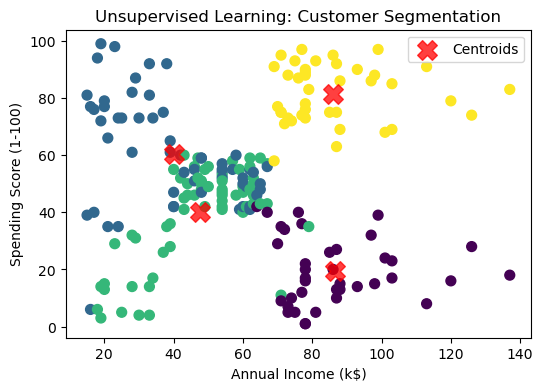

In [107]:
plt.figure(figsize=(6, 4))
plt.scatter(features['Annual_Income_(k$)'], features['Spending_Score'], c=clusters, s=50, cmap='viridis')
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 1], centers[:, 2], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title('Unsupervised Learning: Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [108]:
centers_real = scaler.inverse_transform(kmeans.cluster_centers_)
print(centers_real)

[[39.36842105 86.5        19.57894737]
 [25.43859649 40.         60.29824561]
 [53.98461538 47.70769231 39.96923077]
 [32.875      86.1        81.525     ]]


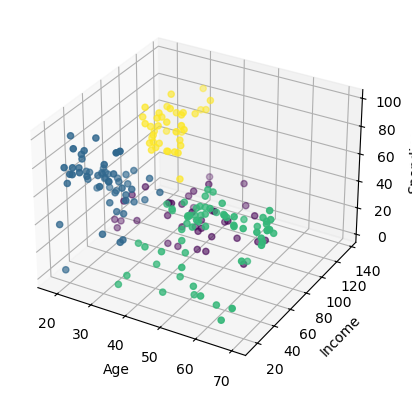

In [109]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(features['Age'], features['Annual_Income_(k$)'], features['Spending_Score'], c=clusters)
ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending")
plt.show()

In [110]:
df.groupby('Cluster_ID')[['Age','Annual_Income_(k$)','Spending_Score']].mean()

,Age,Annual_Income_(k$),Spending_Score
Cluster_ID,,,
0,39.368421,86.500000,19.578947
1,25.438596,40.000000,60.298246
2,53.984615,47.707692,39.969231
3,32.875000,86.100000,81.525000


Cluster 1: Avg age = 39 --> high income, low spending <br>
Cluster 2: Avg age = 25 --> low income, high spending <br>
Cluster 3: Avg age = 54 --> low income, low spending <br>
Cluster 4: Avg age = 33 --> high income, high spending <br>

In [113]:
df['Cluster_ID'].value_counts() #checking how the clusters are spread out

Cluster_ID
2    65
1    57
3    40
0    38
Name: count, dtype: int64

In [112]:
from sklearn.metrics import silhouette_samples

sample = silhouette_samples(scaled_df, clusters)
df['score'] = sample
df.groupby('Cluster_ID')['score'].mean()

Cluster_ID
0    0.341514
1    0.367589
2    0.381888
3    0.550972
Name: score, dtype: float64

In [114]:
#Cluster 3 is strong. used this metric to judge the no. of clusters. k=4 gives the best score. 